In [26]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np

# Define the ports and their corresponding traffic types
port_map = {
    5060: 'VOIP',
    21: 'FTP',
    5000: 'GAMING',
    16384: 'VIDEO'
}

# Load the XML file
flowmon_path="ns-3-dev/multi-links-flow.xml"
tree = ET.parse(flowmon_path)  # Replace with your file path
root = tree.getroot()

# Prepare a list to collect parsed flow data
flow_data = []

# Iterate over all <Flow> elements inside <FlowStats>
#---------------nano seconds to second & bytes to Megabytes
for flow in root.find('FlowStats').findall('Flow'):
    flow_id = int(flow.attrib['flowId'])
    time_first_tx = float(flow.attrib['timeFirstTxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_first_rx = float(flow.attrib['timeFirstRxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_last_tx = float(flow.attrib['timeLastTxPacket'].replace('ns', '').replace('+', ''))*1E-9
    time_last_rx = float(flow.attrib['timeLastRxPacket'].replace('ns', '').replace('+', ''))*1E-9
    delay_sum = float(flow.attrib['delaySum'].replace('ns', '').replace('+', ''))*1E-9
    jitter_sum = float(flow.attrib['jitterSum'].replace('ns', '').replace('+', ''))*1E-9
    last_delay = float(flow.attrib['lastDelay'].replace('ns', '').replace('+', ''))*1E-9
    tx_bytes = int(flow.attrib['txBytes'])
    rx_bytes = int(flow.attrib['rxBytes'])
    tx_packets = int(flow.attrib['txPackets'])
    rx_packets = int(flow.attrib['rxPackets'])
    lost_packets = int(flow.attrib['lostPackets'])
    times_forwarded = int(flow.attrib['timesForwarded'])
    duration = time_last_rx - time_first_tx
    throughput_Mbps = (int(flow.attrib['rxBytes']) * 8) / (duration * 1e6)  # bits/sec → Mbps


    flow_data.append({
        'flow_id': flow_id,
        'time_first_tx_s': time_first_tx,
        'time_first_rx_s': time_first_rx,
        'time_last_tx_s': time_last_tx,
        'time_last_rx_s': time_last_rx,
        'delay_sum_s': delay_sum,
        'jitter_sum_s': jitter_sum,
        'last_delay_s': last_delay,
        'tx_bytes': tx_bytes,
        'rx_bytes': rx_bytes,
        'tx_packets': tx_packets,
        'rx_packets': rx_packets,
        'lost_packets': lost_packets,
        'times_forwarded': times_forwarded,
        'duration':duration,
        'throughput_Mbps':throughput_Mbps
    })

classifier_info = {}

for flow in root.find('Ipv4FlowClassifier').findall('Flow'):
    flow_id = int(flow.attrib['flowId'])

    # Find the <Dscp> child tag inside this flow
    dscp_elem = flow.find('Dscp')
    if dscp_elem is not None:
        # Convert hex string like "0x4" to int
        dscp_hex = dscp_elem.attrib.get('value')
        dscp_val = int(dscp_hex, 16)
        dscp_packets = dscp_elem.attrib.get('packets')
        tos_hex = hex(dscp_val << 2)
        

        
    else:
        dscp_value = None
        tos_val=None
        dscp_packets = None

    classifier_info[flow_id] = {
        'src': flow.attrib['sourceAddress'],
        'dst': flow.attrib['destinationAddress'],
        'src_port': flow.attrib['sourcePort'],
        'dst_port': flow.attrib['destinationPort'],
        'protocol': flow.attrib['protocol'],
        'DSCP': dscp_hex,
        'tos': tos_hex,
        'DSCP_packets': dscp_packets

    }

# Merge with previous stats if needed
for row in flow_data:
    fid = row['flow_id']
    if fid in classifier_info:
        row.update(classifier_info[fid])
df_flowmon = pd.DataFrame(flow_data)
df_flowmon['mean_delay']=  df_flowmon['delay_sum_s']/df_flowmon['rx_packets']
df_flowmon['mean-jitter']=df_flowmon['jitter_sum_s']/df_flowmon['rx_packets']

df_flowmon['flow_5tuple'] = (df_flowmon['src'].astype(str) + '-' +
                         df_flowmon['dst'].astype(str) + '-' +
                         df_flowmon['src_port'].astype(str) + '-' + 
                         df_flowmon['dst_port'].astype(str) + '-' +
                         df_flowmon['protocol'].astype(str)+'-'+
                         df_flowmon['DSCP'].astype(str))
# Conditions for src_port or dst_port in the keys of port_map
conditions = [
    (df_flowmon['src_port'] == '5060') | (df_flowmon['dst_port'] == '5060'),
    (df_flowmon['src_port'] == '21')   | (df_flowmon['dst_port'] == '21'),
    (df_flowmon['src_port'] == '5000') | (df_flowmon['dst_port'] == '5000'),
    (df_flowmon['src_port'] == '16384')| (df_flowmon['dst_port'] == '16384'),
]

choices = ['VOIP', 'FTP', 'GAMING', 'VIDEO']

# Add a new column 'traffic_type' with np.select
df_flowmon['traffic_type'] = np.select(conditions, choices, default='OTHER')


# Check result
print(df_flowmon[['src_port', 'dst_port', 'traffic_type']])

  src_port dst_port traffic_type
0    49153       21          FTP
1    49154    16384        VIDEO
2    49155     5060         VOIP
3       21    49153          FTP
4    16384    49154        VIDEO
5     5060    49155         VOIP
6    49156     5000       GAMING
7     5000    49156       GAMING


Will output direct qnd ACK messages TCP flows (in both directions) and not the logical application flow

In [27]:
df_flowmon.head(2)

,flow_id,time_first_tx_s,time_first_rx_s,time_last_tx_s,time_last_rx_s,delay_sum_s,jitter_sum_s,last_delay_s,tx_bytes,rx_bytes,...,src_port,dst_port,protocol,DSCP,tos,DSCP_packets,mean_delay,mean-jitter,flow_5tuple,traffic_type
0,1,0.5,0.500964,97.9163,98.2595,3177.75,49.2272,0.343204,6195600,6138564,...,49153,21,6,0xa,0x28,10541,0.304266,0.004713,10.1.1.1-10.1.1.2-49153-21-6-0xa,FTP
1,2,0.5,0.501428,200.4930,200.4960,1601.17,32.9811,0.002932,2865901,2865901,...,49154,16384,6,0x1a,0x68,18801,0.085164,0.001754,10.1.1.1-10.1.1.2-49154-16384-6-0x1a,VIDEO


In [28]:
df_flowmon.columns

Index(['flow_id', 'time_first_tx_s', 'time_first_rx_s', 'time_last_tx_s',
       'time_last_rx_s', 'delay_sum_s', 'jitter_sum_s', 'last_delay_s',
       'tx_bytes', 'rx_bytes', 'tx_packets', 'rx_packets', 'lost_packets',
       'times_forwarded', 'duration', 'throughput_Mbps', 'src', 'dst',
       'src_port', 'dst_port', 'protocol', 'DSCP', 'tos', 'DSCP_packets',
       'mean_delay', 'mean-jitter', 'flow_5tuple', 'traffic_type'],
      dtype='object')

In [29]:
df_sorted = df_flowmon.sort_values(by="traffic_type")
df_sorted[['flow_id','DSCP','tos','flow_5tuple','time_last_rx_s','traffic_type','throughput_Mbps','mean_delay', 'mean-jitter','lost_packets']]

,flow_id,DSCP,tos,flow_5tuple,time_last_rx_s,traffic_type,throughput_Mbps,mean_delay,mean-jitter,lost_packets
0,1,0xa,0x28,10.1.1.1-10.1.1.2-49153-21-6-0xa,98.2595,FTP,0.502340,0.304266,4.713443e-03,97
3,4,0xa,0x28,10.1.1.2-10.1.1.1-21-49153-6-0xa,98.2605,FTP,0.028398,0.000970,6.544503e-07,0
6,7,0x22,0x88,10.1.1.1-10.1.1.2-49156-5000-6-0x22,200.4580,GAMING,0.026635,0.086496,4.220560e-03,0
7,8,0x22,0x88,10.1.1.2-10.1.1.1-5000-49156-6-0x22,200.4590,GAMING,0.003604,0.000932,1.847575e-08,0
1,2,0x1a,0x68,10.1.1.1-10.1.1.2-49154-16384-6-0x1a,200.4960,VIDEO,0.114638,0.085164,1.754221e-03,0
4,5,0x1a,0x68,10.1.1.2-10.1.1.1-16384-49154-6-0x1a,200.4970,VIDEO,0.019555,0.000932,3.403893e-09,0
2,3,0x2e,0xb8,10.1.1.1-10.1.1.2-49155-5060-6-0x2e,200.3410,VOIP,0.013463,0.089395,3.272492e-03,0
5,6,0x2e,0xb8,10.1.1.2-10.1.1.1-5060-49155-6-0x2e,200.1820,VOIP,0.004027,0.000932,7.167305e-07,0


inter_packet arrival (to adjust)

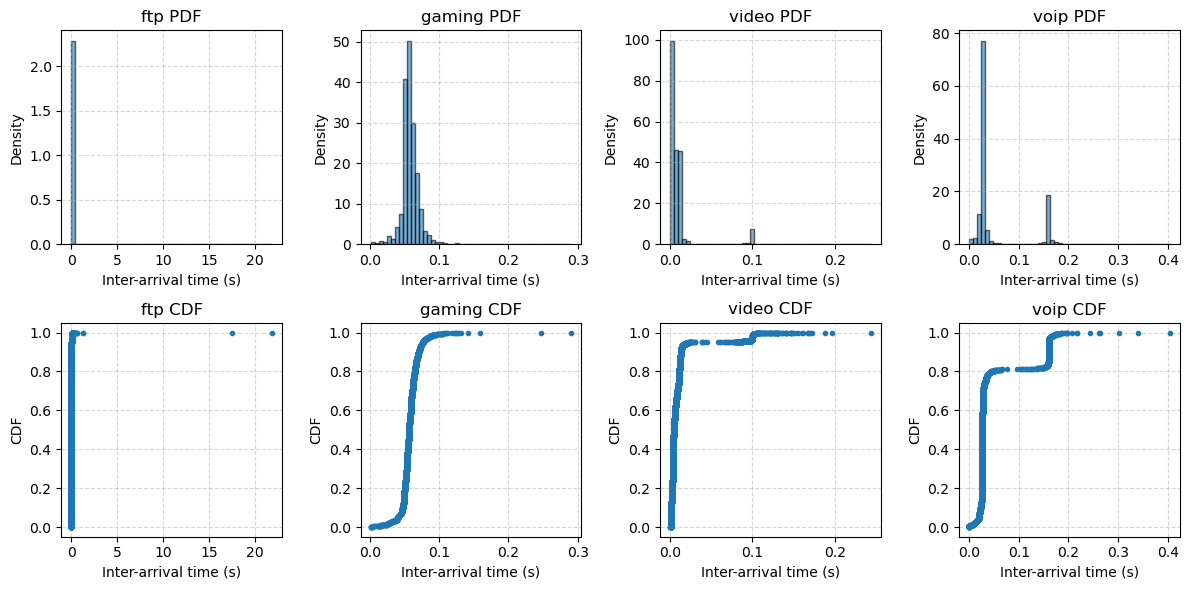

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load file, skipping the comment line
df_packet_rx = pd.read_csv('ns-3-dev/packet_arrival_times.txt', sep="\t",index_col=False)

# Group by traffic type
traffic_groups = df_packet_rx.groupby("TrafficType")
interarrival = {}
times_dict={}
size_dict={}

for ttype, group in traffic_groups:
    times = np.sort(group["Time(s)"].values)  # ensure chronological order
    times_dict[ttype]=times
    sizes=np.sort(group["Size(Bytes)"].values)
    size_dict[ttype]=sizes
    inter_times = np.diff(times)  # compute time differences
    interarrival[ttype] = inter_times
plt.figure(figsize=(12,6))

for i, (ttype, inter_times) in enumerate(interarrival.items(), 1):
    # PDF
    plt.subplot(2, len(interarrival), i)
    plt.hist(inter_times, bins=50, density=True, alpha=0.6, edgecolor="black")
    plt.title(f"{ttype} PDF")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.xlabel("Inter-arrival time (s)")
    plt.ylabel("Density")

    # CDF
    plt.subplot(2, len(interarrival), i + len(interarrival))
    sorted_times = np.sort(inter_times)
    cdf = np.arange(1, len(sorted_times) + 1) / len(sorted_times)
    plt.plot(sorted_times, cdf, marker='.', linestyle='none')
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.title(f"{ttype} CDF")
    plt.xlabel("Inter-arrival time (s)")
    plt.ylabel("CDF")

plt.tight_layout()
plt.show()



In [31]:
df_packet_rx.groupby('TrafficType')['Size(Bytes)'].mean()

TrafficType
ftp       636.174713
gaming    140.315227
video     100.443907
voip       35.214008
Name: Size(Bytes), dtype: float64

Vertical time pulses

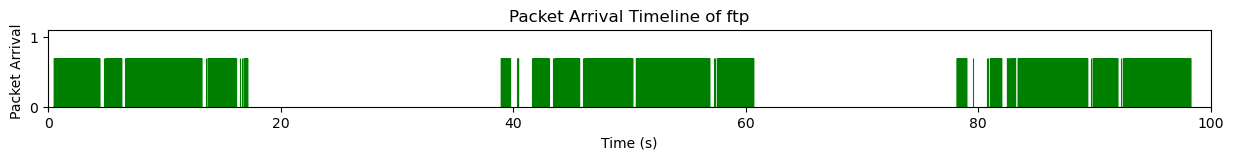

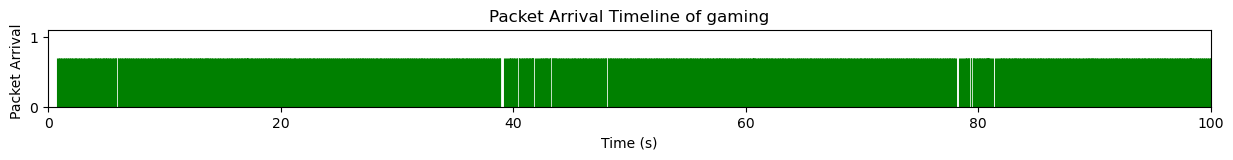

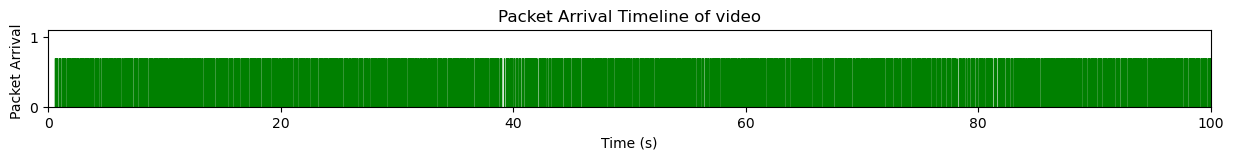

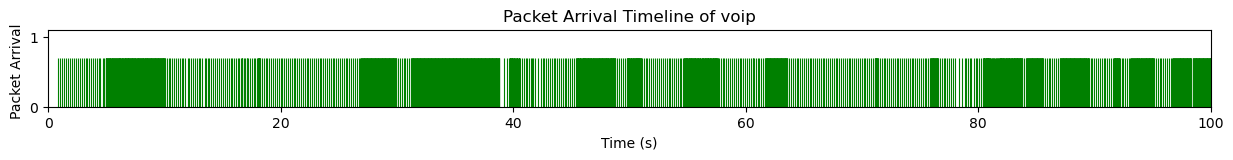

In [32]:
for ttype, time_stamp in times_dict.items():
    # Plot vertical lines at each timestamp
    plt.figure(figsize=(15, 1))
    plt.vlines(time_stamp, ymin=0, ymax=0.7, color="green", linewidth=0.8,alpha=1) 

    # Make it look like a signal timeline
    plt.xlim(0.0, 100)
    plt.ylim(0, 1.1)
    plt.xlabel("Time (s)")
    plt.ylabel("Packet Arrival ")
    plt.title(f"Packet Arrival Timeline of {ttype}")
    plt.show()

In [33]:
"""
plt.figure(figsize=(15, 4))

for flow, ts in times_dict.items():
    sz = size_dict[flow]
    plt.figure(figsize=(15, 4))
    plt.plot(ts,sz)
    #plt.stem(ts, sz, label=flow, linefmt='C0-', markerfmt=' ', basefmt=' ')
    #plt.vlines(ts, ymin=0, ymax=500, color="green", linewidth=0.1)

    plt.xlabel('Time (s)')
    #plt.xlim(0.0, 18)
    #plt.ylim(0.0, 600)
    plt.ylabel('Packet size (bytes)')
    plt.title('Packet pulses per flow')
 
    plt.show()
"""

'\nplt.figure(figsize=(15, 4))\n\nfor flow, ts in times_dict.items():\n    sz = size_dict[flow]\n    plt.figure(figsize=(15, 4))\n    plt.plot(ts,sz)\n    #plt.stem(ts, sz, label=flow, linefmt=\'C0-\', markerfmt=\' \', basefmt=\' \')\n    #plt.vlines(ts, ymin=0, ymax=500, color="green", linewidth=0.1)\n\n    plt.xlabel(\'Time (s)\')\n    #plt.xlim(0.0, 18)\n    #plt.ylim(0.0, 600)\n    plt.ylabel(\'Packet size (bytes)\')\n    plt.title(\'Packet pulses per flow\')\n \n    plt.show()\n'